# ChurnIQ: Telecom Customer Churn & Revenue Risk Analyzer

## 1. Import Libraries

Import the libraries required for data loading and inspection.

In [6]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

## 2. Load Datasets

Load the Cell2Cell train and holdout datasets.

In [7]:
train_df = pd.read_csv("../data/raw/cell2celltrain.csv")
holdout_df = pd.read_csv("../data/raw/cell2cellholdout.csv")

## 3. Inspect Dataset Dimensions

Check the number of rows and columns in both datasets.

In [8]:
print("Train Shape :", train_df.shape)
print("Holdout Shape :", holdout_df.shape)

Train Shape : (51047, 58)
Holdout Shape : (20000, 58)


## Observation

Record important findings from the output above.

Examples:

- Train dataset contains 51047 rows and 58 columns.
- Holdout dataset contains 20000 rows and 58 columns.
- Both datasets appear structurally consistent.

In [9]:
train_df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


## 4. Preview Dataset

Display the first few records to understand the structure and available information.

## 5. Inspect Column Names

Review all available variables in the dataset.

In [10]:
train_df.columns.tolist()

['CustomerID',
 'Churn',
 'MonthlyRevenue',
 'MonthlyMinutes',
 'TotalRecurringCharge',
 'DirectorAssistedCalls',
 'OverageMinutes',
 'RoamingCalls',
 'PercChangeMinutes',
 'PercChangeRevenues',
 'DroppedCalls',
 'BlockedCalls',
 'UnansweredCalls',
 'CustomerCareCalls',
 'ThreewayCalls',
 'ReceivedCalls',
 'OutboundCalls',
 'InboundCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'DroppedBlockedCalls',
 'CallForwardingCalls',
 'CallWaitingCalls',
 'MonthsInService',
 'UniqueSubs',
 'ActiveSubs',
 'ServiceArea',
 'Handsets',
 'HandsetModels',
 'CurrentEquipmentDays',
 'AgeHH1',
 'AgeHH2',
 'ChildrenInHH',
 'HandsetRefurbished',
 'HandsetWebCapable',
 'TruckOwner',
 'RVOwner',
 'Homeownership',
 'BuysViaMailOrder',
 'RespondsToMailOffers',
 'OptOutMailings',
 'NonUSTravel',
 'OwnsComputer',
 'HasCreditCard',
 'RetentionCalls',
 'RetentionOffersAccepted',
 'NewCellphoneUser',
 'NotNewCellphoneUser',
 'ReferralsMadeBySubscriber',
 'IncomeGroup',
 'OwnsMotorcycle',
 'AdjustmentsToCreditRat

## 6. Inspect Data Types

Understand the datatype of each feature.

In [11]:
train_df.dtypes

CustomerID                     int64
Churn                         object
MonthlyRevenue               float64
MonthlyMinutes               float64
TotalRecurringCharge         float64
DirectorAssistedCalls        float64
OverageMinutes               float64
RoamingCalls                 float64
PercChangeMinutes            float64
PercChangeRevenues           float64
DroppedCalls                 float64
BlockedCalls                 float64
UnansweredCalls              float64
CustomerCareCalls            float64
ThreewayCalls                float64
ReceivedCalls                float64
OutboundCalls                float64
InboundCalls                 float64
PeakCallsInOut               float64
OffPeakCallsInOut            float64
DroppedBlockedCalls          float64
CallForwardingCalls          float64
CallWaitingCalls             float64
MonthsInService                int64
UniqueSubs                     int64
ActiveSubs                     int64
ServiceArea                   object
H

## 7. Dataset Information

Analyze:

- Number of non-null values
- Datatypes
- Memory usage

In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

## 8. Missing Value Assessment

Identify features containing missing values and quantify their magnitude.

In [13]:
train_df.isnull().sum().sort_values(ascending=False)

AgeHH2                       909
AgeHH1                       909
PercChangeMinutes            367
PercChangeRevenues           367
MonthlyRevenue               156
MonthlyMinutes               156
TotalRecurringCharge         156
DirectorAssistedCalls        156
OverageMinutes               156
RoamingCalls                 156
ServiceArea                   24
CurrentEquipmentDays           1
Handsets                       1
HandsetModels                  1
OwnsComputer                   0
NonUSTravel                    0
BuysViaMailOrder               0
OptOutMailings                 0
RespondsToMailOffers           0
RetentionCalls                 0
HasCreditCard                  0
IncomeGroup                    0
RetentionOffersAccepted        0
NewCellphoneUser               0
NotNewCellphoneUser            0
ReferralsMadeBySubscriber      0
RVOwner                        0
OwnsMotorcycle                 0
AdjustmentsToCreditRating      0
HandsetPrice                   0
MadeCallTo

In [14]:
missing = train_df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

AgeHH1                   909
AgeHH2                   909
PercChangeMinutes        367
PercChangeRevenues       367
MonthlyRevenue           156
MonthlyMinutes           156
TotalRecurringCharge     156
DirectorAssistedCalls    156
OverageMinutes           156
RoamingCalls             156
ServiceArea               24
Handsets                   1
HandsetModels              1
CurrentEquipmentDays       1
dtype: int64

## 9. Target Variable Investigation

### Objective

Identify the target variable and understand its distribution before modeling.

Understanding class balance is critical because churn prediction is a classification problem and class imbalance can significantly impact model performance.

In [18]:
train_df["Churn"].value_counts()

Churn
No     36336
Yes    14711
Name: count, dtype: int64

In [19]:
train_df["Churn"].value_counts(normalize=True) * 100

Churn
No     71.18146
Yes    28.81854
Name: proportion, dtype: float64

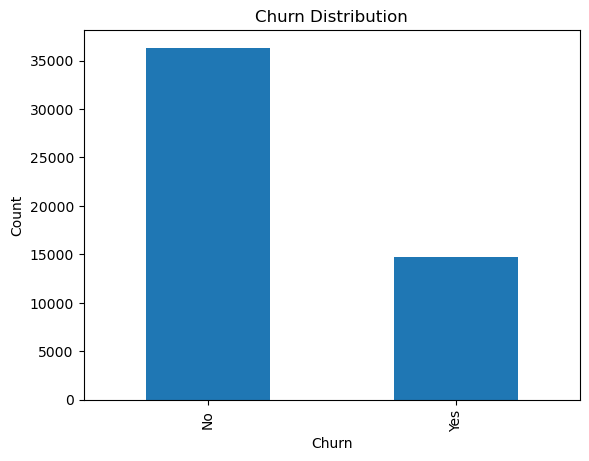

In [21]:
import matplotlib.pyplot as plt

train_df["Churn"].value_counts().plot(kind="bar")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

## 10. Unique Customer Verification

### Objective

Verify whether CustomerID uniquely identifies each customer.

In [22]:
train_df["CustomerID"].nunique()

51047

In [23]:
len(train_df)

51047

In [24]:
holdout_df.columns.tolist()

['CustomerID',
 'Churn',
 'MonthlyRevenue',
 'MonthlyMinutes',
 'TotalRecurringCharge',
 'DirectorAssistedCalls',
 'OverageMinutes',
 'RoamingCalls',
 'PercChangeMinutes',
 'PercChangeRevenues',
 'DroppedCalls',
 'BlockedCalls',
 'UnansweredCalls',
 'CustomerCareCalls',
 'ThreewayCalls',
 'ReceivedCalls',
 'OutboundCalls',
 'InboundCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'DroppedBlockedCalls',
 'CallForwardingCalls',
 'CallWaitingCalls',
 'MonthsInService',
 'UniqueSubs',
 'ActiveSubs',
 'ServiceArea',
 'Handsets',
 'HandsetModels',
 'CurrentEquipmentDays',
 'AgeHH1',
 'AgeHH2',
 'ChildrenInHH',
 'HandsetRefurbished',
 'HandsetWebCapable',
 'TruckOwner',
 'RVOwner',
 'Homeownership',
 'BuysViaMailOrder',
 'RespondsToMailOffers',
 'OptOutMailings',
 'NonUSTravel',
 'OwnsComputer',
 'HasCreditCard',
 'RetentionCalls',
 'RetentionOffersAccepted',
 'NewCellphoneUser',
 'NotNewCellphoneUser',
 'ReferralsMadeBySubscriber',
 'IncomeGroup',
 'OwnsMotorcycle',
 'AdjustmentsToCreditRat

### Observation

#### Target Variable Distribution

- No (Retained Customers): 36,336
- Yes (Churned Customers): 14,711

#### Percentage Distribution

- Retained Customers: 71.18%
- Churned Customers: 28.82%

#### CustomerID Verification

- Unique CustomerIDs: 51,047
- Total Rows: 51,047

Therefore, CustomerID uniquely identifies each customer.

### Business Insight

Approximately 29% of customers have churned.

This represents a significant business problem because nearly one out of every three customers leaves the service.

The dataset shows moderate class imbalance, but it is not severe enough to require immediate resampling decisions during the data understanding phase.

CustomerID appears to be a unique identifier and is unlikely to carry predictive value for churn behavior.

### Interview Note

Target distribution was analyzed before modeling to assess class balance.

The churn rate is approximately 29%, indicating a moderately imbalanced classification problem.

CustomerID was verified as a unique identifier and will likely be excluded from model training to avoid introducing non-informative features.

## 11. Feature Categorization

### Objective

Group variables into meaningful business categories to improve understanding of customer behavior and support later analysis.

This categorization will help during:

- Exploratory Data Analysis
- Feature Engineering
- Model Explainability
- Business Recommendations

In [25]:
train_df.columns.tolist()

['CustomerID',
 'Churn',
 'MonthlyRevenue',
 'MonthlyMinutes',
 'TotalRecurringCharge',
 'DirectorAssistedCalls',
 'OverageMinutes',
 'RoamingCalls',
 'PercChangeMinutes',
 'PercChangeRevenues',
 'DroppedCalls',
 'BlockedCalls',
 'UnansweredCalls',
 'CustomerCareCalls',
 'ThreewayCalls',
 'ReceivedCalls',
 'OutboundCalls',
 'InboundCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'DroppedBlockedCalls',
 'CallForwardingCalls',
 'CallWaitingCalls',
 'MonthsInService',
 'UniqueSubs',
 'ActiveSubs',
 'ServiceArea',
 'Handsets',
 'HandsetModels',
 'CurrentEquipmentDays',
 'AgeHH1',
 'AgeHH2',
 'ChildrenInHH',
 'HandsetRefurbished',
 'HandsetWebCapable',
 'TruckOwner',
 'RVOwner',
 'Homeownership',
 'BuysViaMailOrder',
 'RespondsToMailOffers',
 'OptOutMailings',
 'NonUSTravel',
 'OwnsComputer',
 'HasCreditCard',
 'RetentionCalls',
 'RetentionOffersAccepted',
 'NewCellphoneUser',
 'NotNewCellphoneUser',
 'ReferralsMadeBySubscriber',
 'IncomeGroup',
 'OwnsMotorcycle',
 'AdjustmentsToCreditRat

## 12. Business Feature Categorization

### Objective

Organize features into business-relevant groups to improve dataset understanding and support future EDA, feature engineering, model explainability, and business recommendations.

## Feature Categorization

Features were grouped into business-oriented categories such as:

- Revenue
- Usage
- Subscription
- Device
- Demographic
- Marketing
- Retention
- Financial
- Geographic

This categorization will guide future EDA and feature engineering activities.

## 13. Categorical Feature Exploration

### Objective

Inspect important categorical features to understand customer segments, identify unknown values, and detect potential data quality issues.

In [27]:
categorical_cols = [
    "Churn",
    "CreditRating",
    "PrizmCode",
    "Occupation",
    "MaritalStatus",
    "Homeownership"
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")
    print(train_df[col].value_counts(dropna=False))


Churn
Churn
No     36336
Yes    14711
Name: count, dtype: int64

CreditRating
CreditRating
2-High       18993
1-Highest     8522
3-Good        8410
5-Low         6499
4-Medium      5357
7-Lowest      2114
6-VeryLow     1152
Name: count, dtype: int64

PrizmCode
PrizmCode
Other       24655
Suburban    16378
Town         7589
Rural        2425
Name: count, dtype: int64

Occupation
Occupation
Other           37637
Professional     8755
Crafts           1519
Clerical          986
Self              879
Retired           733
Student           381
Homemaker         157
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Unknown    19700
Yes        18651
No         12696
Name: count, dtype: int64

Homeownership
Homeownership
Known      33987
Unknown    17060
Name: count, dtype: int64


### Observation

- Churn rate is approximately 29%.
- CreditRating appears reasonably distributed across multiple categories.
- PrizmCode contains four major customer segments: Other, Suburban, Town, and Rural.
- Occupation is heavily dominated by the "Other" category.
- MaritalStatus contains a large number of "Unknown" values.
- Homeownership also contains a substantial number of "Unknown" values.

These findings suggest the presence of potentially informative customer segmentation features as well as categorical fields that may require special treatment during data cleaning.

## Data Understanding Summary

### Key Findings

- Train dataset contains 51,047 records and 58 features.
- Holdout dataset contains 20,000 records and 58 features.
- Target variable is Churn.
- Churn rate is approximately 29%.
- Several numerical and categorical features are available covering revenue, usage, demographics, retention activity, and customer profile information.
- Missing values exist in a limited set of variables, particularly AgeHH1, AgeHH2, and usage/revenue-related features.
- Some categorical variables contain a large proportion of "Unknown" values.
- Retention-related variables have been identified for future leakage assessment.

### Next Phase

Proceed to Data Quality Assessment to evaluate duplicates, hidden missing values, invalid values, and potential data leakage.